# University Student Services AI Agent

Week 5 Assignment

Retrieval-Augmented Generation (RAG) with LangGraph

In [29]:
import os

from dotenv import load_dotenv

from typing import TypedDict

from langchain_core.documents import Document

from langchain_openai import (ChatOpenAI, OpenAIEmbeddings)

from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import ChatOllama

from langchain_community.embeddings import HuggingFaceEmbeddings


from langgraph.graph import (StateGraph,START,END)

In [30]:
load_dotenv()

True

In [31]:
#load knowledge documents

knowledge_docs = []

folder_path = "./knowledge_documents"

for filename in os.listdir(folder_path):

    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path,filename)
        with open(file_path, "r", encoding="utf-8") as file:
            text = file.read()
            knowledge_docs.append(
                Document(
                    page_content=text,
                    metadata={
                        "source": filename
                    }
                )
            )

print(
    f"Loaded {len(knowledge_docs)} documents"
)

Loaded 8 documents


In [32]:
for doc in knowledge_docs:

    print("=" * 60)

    print(doc.metadata)

    print(doc.page_content[:300])

{'source': 'campus_services_guide.txt'}
UNIVERSITY CAMPUS SERVICES GUIDE

Version 2026

STUDENT HOUSING

The university offers both on-campus and off-campus housing assistance.

Students interested in on-campus housing must submit a Housing Application before July 1.

Housing assignments are made on a first-come, first-served basis.

Resi
{'source': 'career_services_faq.txt'}
CAREER SERVICES FREQUENTLY ASKED QUESTIONS

GENERAL SERVICES

Q: What services are offered?
A: Resume reviews, career coaching, internship support, mock interviews, networking events, employer presentations, and job search assistance.

Q: Are services free?
A: Yes, all currently enrolled students ma
{'source': 'course_registration_guide.txt'}
COURSE REGISTRATION GUIDE
Academic Year 2026–2027

OVERVIEW

The registration process allows students to enroll in courses required for degree completion. Students are responsible for ensuring registration accuracy and compliance with academic policies.

REGISTRATION PERIODS


In [33]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(
    knowledge_docs
)

print(
    f"Created {len(chunks)} chunks"
)

Created 19 chunks


In [34]:
chunks[0]

Document(metadata={'source': 'campus_services_guide.txt'}, page_content='UNIVERSITY CAMPUS SERVICES GUIDE\n\nVersion 2026\n\nSTUDENT HOUSING\n\nThe university offers both on-campus and off-campus housing assistance.\n\nStudents interested in on-campus housing must submit a Housing Application before July 1.\n\nHousing assignments are made on a first-come, first-served basis.\n\nResidence halls include:\n\n- Maple Hall\n- Oak Hall\n- Cedar Hall\n\nLIBRARY SERVICES\n\nThe University Library operates:\n\nMonday - Friday:\n8:00 AM - 10:00 PM\n\nSaturday:\n9:00 AM - 6:00 PM\n\nSunday:\n12:00 PM - 8:00 PM\n\nStudents may borrow up to 10 books simultaneously.\n\nLibrary services include:\n\n- Book lending\n- Research assistance\n- Digital databases\n- Study rooms\n- Printing services\n\nIT SUPPORT\n\nThe IT Help Desk provides technical assistance for:\n\n- Student email accounts\n- Learning Management System access\n- Wi-Fi connectivity\n- Password resets\n- Software installation\n\nSupport H

In [35]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5078.21it/s]


In [36]:
unique_chunks = []
seen = set()

for chunk in chunks:

    content = chunk.page_content.strip()

    if content not in seen:
        seen.add(content)
        unique_chunks.append(chunk)

print(f"Original chunks: {len(chunks)}")
print(f"Unique chunks: {len(unique_chunks)}")

Original chunks: 19
Unique chunks: 19


In [37]:
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./student_service_db"
)

In [38]:
retriever = vector_store.as_retriever(
    search_kwargs={ "k": 5  }
)

In [39]:
collection = vector_store._collection

print(collection.count())

19


In [55]:
print(collection.count())
print(len(chunks))

19
19


In [40]:
results = retriever.invoke(
    "What GPA is required for graduation?"
)

for doc in results:

    print(doc.metadata)

    print(doc.page_content[:500])

    print("="*50)

{'source': 'student_handbook.txt'}
UNIVERSITY STUDENT HANDBOOK

Version 2026

ACADEMIC POLICIES

Students are expected to maintain satisfactory academic progress throughout their studies.

A minimum cumulative GPA of 2.5 is required for graduation from undergraduate programs.

Students whose GPA falls below 2.0 will be placed on Academic Probation.

Students on Academic Probation for two consecutive semesters may be subject to Academic Suspension.

GRADING SYSTEM

A = 90 - 100
B = 80 - 89
C = 70 - 79
D = 60 - 69
F = Below 60

ATT
{'source': 'financial_aid_guide.txt'}
SATISFACTORY ACADEMIC PROGRESS

Students must:
- Maintain a GPA of at least 2.0.
- Successfully complete at least 67% of attempted credits.

VERIFICATION

Selected students may be required to submit:
- Tax documents
- Income verification
- Household information

SCHOLARSHIPS

Academic Excellence Scholarship:
GPA 3.8 or higher.

Leadership Scholarship:
Demonstrated leadership and service.

Community Impact Scholarship:
Volu

In [41]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3",
    temperature=0
)


In [42]:
print(llm)

output_version=None model='llama3' temperature=0.0


In [43]:
class AgentState(TypedDict):

    question: str

    route: str

    documents: list

    answer: str

    reviewed_answer: str

In [44]:
def route_question(state):

    question = state["question"]

    prompt = f"""
    Classify the question.

    Return only:

    knowledge

    or

    general

    Question:
    {question}
    """

    response = llm.invoke(prompt)

    print("RAW RESPONSE:", response.content)

    route = response.content.strip().lower()

    print("ROUTE:", route)

    return {
        "route": route
    }

In [45]:
def retrieve_documents(state):

    docs = retriever.invoke(state["question"])

    unique_docs = []
    seen = set()

    for doc in docs:

        content = doc.page_content.strip()

        if content not in seen:
            seen.add(content)
            unique_docs.append(doc)

    return {
        "documents": unique_docs
    }

In [46]:
def generate_rag_answer(state):

    context = "\n\n".join(doc.page_content
        for doc in state["documents"]
    )

    prompt = f"""You are a university assistant.
    Use ONLY the information contained in the context.
    If the answer cannot be found,
    respond:
    "I could not find that information
    in the university documents."

    Context:
    {context}

    Question:
    {state['question']}
    """

    answer = (
        llm.invoke(prompt).content
    )

    return {
        "answer": answer
    }

In [47]:
def generate_general_answer(state):

    answer = llm.invoke(state["question"]).content

    return {
        "answer": answer
    }

In [48]:
def review_answer(state):

    answer = state["answer"]

    prompt = f"""
    You are an editor.

    Review the answer below.

    If improvements are needed, rewrite the answer.

    If no improvements are needed, return the answer exactly as it is.

    IMPORTANT:
    Return ONLY the final revised answer.
    Do NOT explain your review.
    Do NOT give feedback.
    Do NOT mention clarity, grammar, or completeness.

    Answer:
    {answer}
    """

    response = llm.invoke(prompt)

    return {
        "reviewed_answer": response.content.strip()
    }

In [49]:
def determine_path(state):

    return state["route"]

In [50]:
graph = StateGraph(AgentState)

graph.add_node("router", route_question)
graph.add_node("retrieve",retrieve_documents)
graph.add_node("rag_answer", generate_rag_answer)
graph.add_node("general_answer", generate_general_answer)
graph.add_node("review", review_answer)

In [51]:
graph.add_edge( START,"router")
graph.add_conditional_edges("router", determine_path,
    {
        "knowledge": "retrieve",
        "general": "general_answer"
    }
)
graph.add_edge("retrieve", "rag_answer")
graph.add_edge("rag_answer", "review")
graph.add_edge("general_answer", "review")
graph.add_edge( "review", END)

In [52]:
workflow = graph.compile()

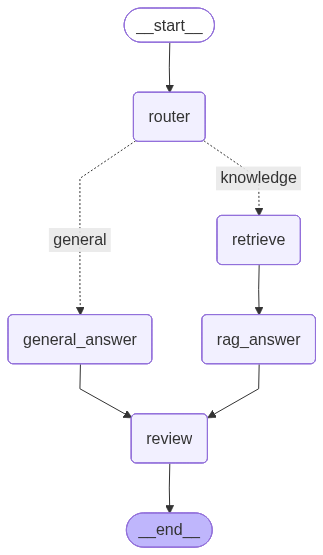

In [57]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

# Testing the University Student Services AI Agent

In [ ]:
test_questions = [
    "What GPA do I need to graduate?",
    "What is the attendance policy?",
    "What happens if a student violates the code of conduct?"
]

for question in test_questions:

    print("=" * 100)
    print("QUESTION:", question)

    response = workflow.invoke({
        "question": question
    })

    print("\nANSWER:")
    print(response["reviewed_answer"])

In [ ]:
#from langgraph.checkpoint.memory import ( MemorySaver)

#memory = MemorySaver()

#workflow = graph.compile(
 #   checkpointer=memory
#)

In [ ]:
#config = {
#    "configurable": {
 #       "thread_id": "student_001"
#    }
#}

In [54]:
result = workflow.invoke(
    {
        "question":
        "What GPA is required for graduation?"
    }
)

print(result["reviewed_answer"])

RAW RESPONSE: knowledge
ROUTE: knowledge
According to the University Student Handbook, a minimum cumulative GPA of 2.5 is required for graduation from undergraduate programs.
